# NLP Project 11: Job Resume Screening

**Kaggle Dataset:** Resume Dataset

The dataset contains 2400+ resumes with `Resume_str` text and `Category` job-category labels.

**Tasks:** collect resume data, preprocess resume text, extract skills and qualifications, match resumes with job roles, and generate a candidate shortlist.

In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(
        LEMMATIZER.lemmatize(w) for w in text.split()
        if w not in STOP_WORDS and len(w) > 2
    )

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(f"Weighted Precision: {pre*100:.2f}%")
    print(f"Weighted Recall: {rec*100:.2f}%")
    print(f"Weighted F1: {f1*100:.2f}%")
    print(classification_report(y_test, pred, zero_division=0))
    return pred, acc, pre, rec, f1


## 1. Download the Dataset

In [3]:
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print("Dataset path:", path)
for root, dirs, files in os.walk(path):
    if files: print(root, files[:10])

100%|██████████| 62.5M/62.5M [00:00<00:00, 68.0MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1
/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1/data/data/DIGITAL-MEDIA ['24953921.pdf', '13837784.pdf', '18354623.pdf', '40311088.pdf', '16893572.pdf', '25525152.pdf', '18488289.pdf', '30504149.pdf', '17432318.pdf', '14209965.pdf']
/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1/data/data/AVIATION ['23985183.pdf', '99416532.pdf', '17686472.pdf', '54232810.pdf', '26888302.pdf', '14790629.pdf', '12192507.pdf', '22442947.pdf', '33627938.pdf', '10395944.pdf']
/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1/data/data/SALES ['29184740.pdf', '58428843.pdf', '25810233.pdf', '37540732.pdf', '79376680.pdf', '55477468.pdf', '16223371.pdf', '28867567.pdf', '18885231.pdf', '20552814.pdf']
/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1/data/data/ADVOCATE ['20272792.pdf', '30741799.pdf', '19234823.pdf', '29173771.pdf', 

## 2. Load the CSV

In [4]:
csv_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))
print(csv_files)
csv_file = max(csv_files, key=os.path.getsize)
df = pd.read_csv(csv_file)
print("Shape:", df.shape)
display(df.head())

['/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1/Resume/Resume.csv']
Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## 3. Inspect and Clean

In [5]:
print(df.columns.tolist())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df = df.dropna(subset=["resume_str", "category"]).drop_duplicates(subset=["resume_str", "category"])
print("Clean shape:", df.shape)
print(df["category"].value_counts())

['ID', 'Resume_str', 'Resume_html', 'Category']
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64
Duplicates: 0
Clean shape: (2482, 4)
category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   117
FITNESS                   117
SALES                     116
AVIATION                  116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


## 4. Resume Category Distribution

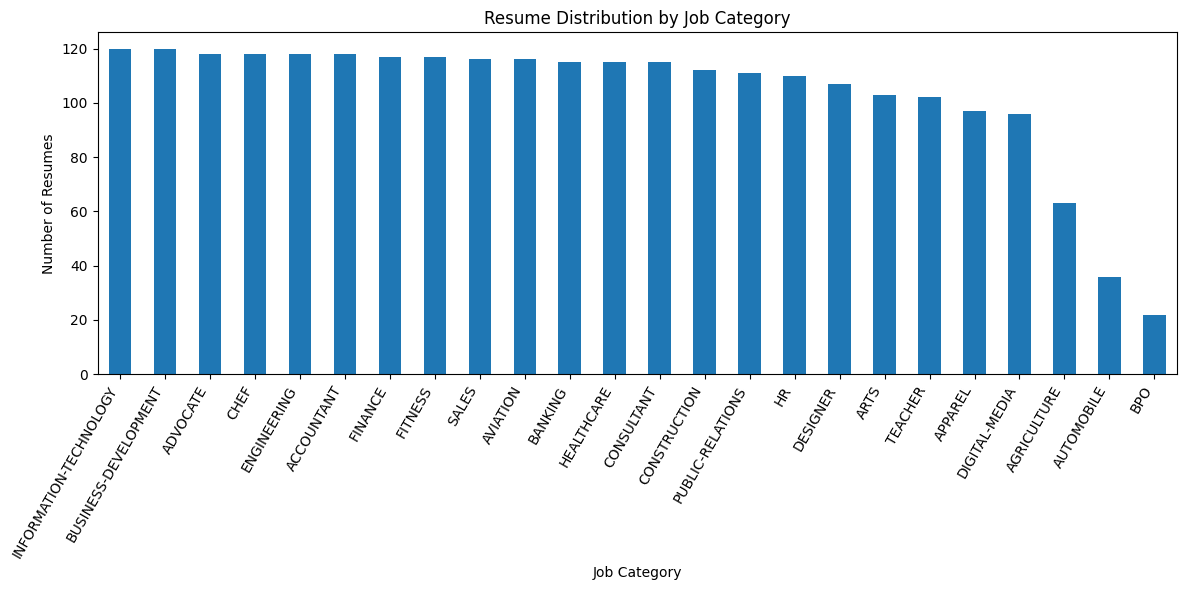

In [6]:
plt.figure(figsize=(12,6))
df["category"].value_counts().plot(kind="bar")
plt.title("Resume Distribution by Job Category")
plt.xlabel("Job Category"); plt.ylabel("Number of Resumes")
plt.xticks(rotation=60, ha="right")
plt.tight_layout(); plt.show()

## 5. Text Preprocessing

In [7]:
df["clean_resume"] = df["resume_str"].apply(preprocess_text)
display(df[["resume_str","clean_resume","category"]].head())

,resume_str,clean_resume,category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,administrator marketing associate administrato...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",specialist operation summary versatile medium ...,HR
2,HR DIRECTOR Summary Over 2...,director summary year experience recruiting pl...,HR
3,HR SPECIALIST Summary Dedica...,specialist summary dedicated driven dynamic ye...,HR
4,HR MANAGER Skill Highlights ...,manager skill highlight skill department start...,HR


## 6. Extract Skills and Qualifications

In [8]:
skill_dictionary = {
    "python":["python","pandas","numpy","scikit learn","tensorflow","pytorch"],
    "sql":["sql","mysql","postgresql","database"],
    "machine learning":["machine learning","scikit learn","tensorflow","pytorch"],
    "data analysis":["data analysis","data analytics","excel","tableau","power bi"],
    "java":["java","spring","hibernate"],
    "javascript":["javascript","react","node","angular"],
    "cloud":["aws","azure","gcp","google cloud"],
    "communication":["communication","presentation","interpersonal"],
    "project management":["project management","agile","scrum","jira"]
}
def extract_skills(text):
    text = str(text).lower()
    return [s for s, words in skill_dictionary.items() if any(w in text for w in words)]

df["skills"] = df["resume_str"].apply(extract_skills)
df["skill_count"] = df["skills"].str.len()

skill_counts = Counter(s for skills in df["skills"] for s in skills)
skill_df = pd.DataFrame(skill_counts.most_common(), columns=["Skill","Frequency"])
display(skill_df)

,Skill,Frequency
0,communication,1784
1,data analysis,1664
2,sql,727
3,project management,596
4,cloud,316
5,java,213
6,javascript,106
7,python,41
8,machine learning,13


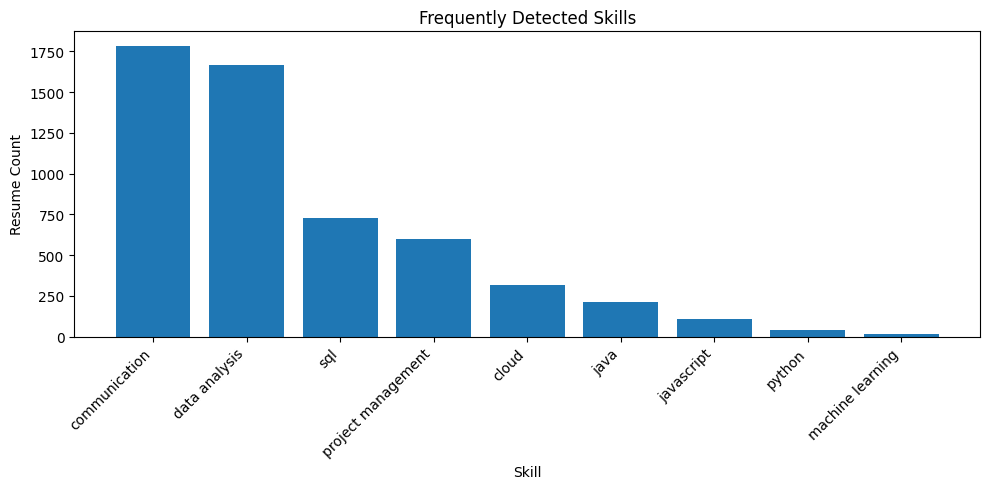

In [9]:
plt.figure(figsize=(10,5))
plt.bar(skill_df["Skill"], skill_df["Frequency"])
plt.title("Frequently Detected Skills")
plt.xlabel("Skill"); plt.ylabel("Resume Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 7. TF-IDF Resume Representation

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_resume"], df["category"].astype(str),
    test_size=0.20, random_state=42, stratify=df["category"].astype(str)
)
vectorizer = TfidfVectorizer(stop_words="english", max_features=15000, ngram_range=(1,2), min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(X_train.shape, X_test.shape)

(1985, 15000) (497, 15000)


## 8. Multinomial Naive Bayes

In [11]:
nb = MultinomialNB().fit(X_train, y_train)
nb_pred, nb_acc, nb_pre, nb_rec, nb_f1 = evaluate_model("Multinomial NB", nb, X_test, y_test)

Multinomial NB Accuracy: 54.53%
Weighted Precision: 60.63%
Weighted Recall: 54.53%
Weighted F1: 50.58%
                        precision    recall  f1-score   support

            ACCOUNTANT       0.47      0.88      0.61        24
              ADVOCATE       0.31      0.42      0.36        24
           AGRICULTURE       1.00      0.08      0.14        13
               APPAREL       0.00      0.00      0.00        19
                  ARTS       1.00      0.14      0.25        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.82      0.61      0.70        23
               BANKING       0.87      0.57      0.68        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.36      0.88      0.51        24
                  CHEF       0.82      0.75      0.78        24
          CONSTRUCTION       0.65      0.68      0.67        22
            CONSULTANT       1.00      0.04      0.08        23


## 9. Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=2000).fit(X_train, y_train)
lr_pred, lr_acc, lr_pre, lr_rec, lr_f1 = evaluate_model("Logistic Regression", lr, X_test, y_test)

Logistic Regression Accuracy: 63.38%
Weighted Precision: 64.60%
Weighted Recall: 63.38%
Weighted F1: 61.44%
                        precision    recall  f1-score   support

            ACCOUNTANT       0.54      0.83      0.66        24
              ADVOCATE       0.31      0.42      0.36        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       0.50      0.11      0.17        19
                  ARTS       0.50      0.29      0.36        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.85      0.74      0.79        23
               BANKING       0.88      0.61      0.72        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.50      0.88      0.64        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.85      0.77      0.81        22
            CONSULTANT       0.40      0.17      0.24      

## 10. GridSearchCV

In [13]:
grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    {"C":[0.5,1.0,2.0], "solver":["liblinear"]},
    cv=3, scoring="f1_weighted", n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_
grid_pred, grid_acc, grid_pre, grid_rec, grid_f1 = evaluate_model(
    "Tuned Logistic Regression", best_model, X_test, y_test
)

Best parameters: {'C': 2.0, 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 65.59%
Weighted Precision: 67.31%
Weighted Recall: 65.59%
Weighted F1: 64.19%
                        precision    recall  f1-score   support

            ACCOUNTANT       0.56      0.83      0.67        24
              ADVOCATE       0.35      0.46      0.40        24
           AGRICULTURE       1.00      0.54      0.70        13
               APPAREL       0.50      0.16      0.24        19
                  ARTS       0.53      0.38      0.44        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.81      0.74      0.77        23
               BANKING       0.79      0.65      0.71        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.58      0.92      0.71        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.85      0.77      0.81        22
  

## 11. Model Comparison

,Model,Accuracy (%),Weighted F1 (%)
0,Multinomial NB,54.53,50.58
1,Logistic Regression,63.38,61.44
2,Tuned Logistic Regression,65.59,64.19


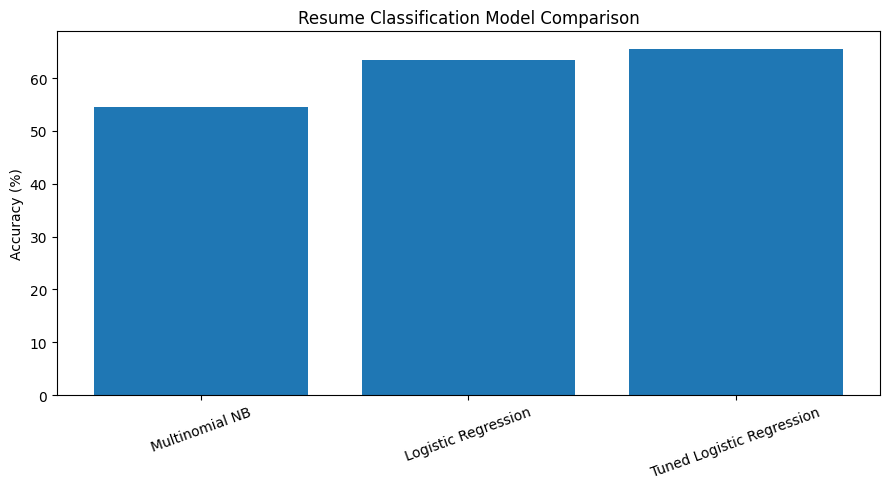

In [14]:
comparison = pd.DataFrame({
    "Model":["Multinomial NB","Logistic Regression","Tuned Logistic Regression"],
    "Accuracy (%)":[nb_acc*100,lr_acc*100,grid_acc*100],
    "Weighted F1 (%)":[nb_f1*100,lr_f1*100,grid_f1*100]
})
display(comparison.round(2))
plt.figure(figsize=(9,5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.title("Resume Classification Model Comparison")
plt.ylabel("Accuracy (%)"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

## 12. Match Resumes with Job Roles

In [15]:
job_roles = {
    "Data Scientist":"python machine learning statistics data analysis pandas numpy scikit learn tensorflow sql",
    "Software Developer":"python java javascript software development programming database api git",
    "Data Analyst":"python sql excel data analysis visualization tableau power bi statistics",
    "HR":"human resources recruitment employee relations communication hiring talent management",
    "Finance":"finance accounting financial analysis banking excel reporting investment"
}
role_names = list(job_roles)
role_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2))
role_matrix = role_vectorizer.fit_transform([preprocess_text(v) for v in job_roles.values()])

match_df = df.head(5000).copy()
resume_matrix = role_vectorizer.transform(match_df["clean_resume"])
scores = cosine_similarity(resume_matrix, role_matrix)
match_df["matched_role"] = [role_names[i] for i in scores.argmax(axis=1)]
match_df["match_score"] = scores.max(axis=1)

display(match_df[["category","matched_role","match_score","skills"]].sort_values("match_score",ascending=False).head(15))

,category,matched_role,match_score,skills
55,HR,HR,0.703904,"[sql, communication, project management]"
105,HR,HR,0.694913,"[data analysis, communication]"
977,BPO,HR,0.691281,[communication]
32,HR,HR,0.679433,"[data analysis, cloud, communication]"
77,HR,HR,0.655172,"[sql, data analysis, cloud, communication]"
21,HR,HR,0.651528,"[data analysis, communication, project managem..."
758,HEALTHCARE,HR,0.647440,"[sql, cloud, communication]"
81,HR,HR,0.641626,"[sql, data analysis, cloud, communication]"
14,HR,HR,0.633190,"[sql, cloud, communication]"
33,HR,HR,0.632863,"[sql, data analysis, cloud, communication]"


## 13. Generate Candidate Shortlist

In [16]:
SHORTLIST_THRESHOLD = 0.20
shortlist = match_df[match_df["match_score"] >= SHORTLIST_THRESHOLD].copy()
shortlist = shortlist.sort_values(["matched_role","match_score"], ascending=[True,False])
shortlist["rank"] = shortlist.groupby("matched_role").cumcount()+1

print("Shortlisted candidates:", len(shortlist))
display(shortlist[["rank","category","matched_role","match_score","skill_count","skills"]].head(30))

Shortlisted candidates: 2292


,rank,category,matched_role,match_score,skill_count,skills
1339,1,AUTOMOBILE,Data Analyst,0.478703,3,"[python, sql, data analysis]"
1303,2,DIGITAL-MEDIA,Data Analyst,0.441542,6,"[python, sql, data analysis, java, javascript,..."
1724,3,ENGINEERING,Data Analyst,0.404216,2,"[sql, data analysis]"
778,4,HEALTHCARE,Data Analyst,0.383190,3,"[sql, data analysis, project management]"
1040,5,SALES,Data Analyst,0.372067,4,"[sql, machine learning, data analysis, communi..."
662,6,BUSINESS-DEVELOPMENT,Data Analyst,0.362376,5,"[python, sql, data analysis, java, project man..."
1273,7,DIGITAL-MEDIA,Data Analyst,0.361496,6,"[sql, data analysis, java, javascript, communi..."
1627,8,APPAREL,Data Analyst,0.357158,2,"[data analysis, communication]"
928,9,AGRICULTURE,Data Analyst,0.350809,1,[data analysis]
672,10,BUSINESS-DEVELOPMENT,Data Analyst,0.343580,3,"[sql, java, communication]"


## 14. Screen a New Resume

In [17]:
def screen_resume(resume_text):
    cleaned = preprocess_text(resume_text)
    category = best_model.predict(vectorizer.transform([cleaned]))[0]
    scores = cosine_similarity(role_vectorizer.transform([cleaned]), role_matrix)[0]
    i = scores.argmax()
    return {
        "Predicted Category": category,
        "Matched Job Role": role_names[i],
        "Match Score": round(float(scores[i]),3),
        "Detected Skills": extract_skills(resume_text)
    }

sample_resume = "Python developer with machine learning, pandas, NumPy, SQL, scikit-learn and Power BI experience."
screen_resume(sample_resume)

{'Predicted Category': 'ENGINEERING',
 'Matched Job Role': 'Data Scientist',
 'Match Score': 0.67,
 'Detected Skills': ['python', 'sql', 'machine learning', 'data analysis']}

## 15. Conclusion

The project preprocesses resumes, extracts relevant skills, classifies resumes into job categories, matches resumes to job-role descriptions using TF-IDF cosine similarity, and generates a ranked candidate shortlist.

All evaluation metrics are calculated from the actual dataset when the notebook is executed.